In [2]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from util import load_experiment, random_quantiles

In [3]:
model_12hr, dataset, config = load_experiment('9e261057-b3c0-4cd9-81ed-d902d1b6b9f7', '../../data/processed/dataset_clean_no-outliers.csv')
model_24hr, _, _ = load_experiment('2ce691e4-a9a2-4d93-ad1c-bc388e01fc94', '../../data/processed/dataset_clean.csv')
model_48hr, _, _ = load_experiment('473bcb9c-a3c7-42f8-aee6-34bb68a21596', '../../data/processed/dataset_clean.csv')
model_72hr, _, _ = load_experiment('036fcb8d-379b-45ef-822b-eaaadd2123ab', '../../data/processed/dataset_clean.csv')
model_96hr, _, _ = load_experiment('9e6c4f5d-7c7d-470c-95a5-1ca144507cbc', '../../data/processed/dataset_clean.csv')
model_120hr, _, _ = load_experiment('dcbc8111-da7c-4db8-b63c-fc66504c0ac2', '../../data/processed/dataset_clean.csv')
model_144hr, _, _ = load_experiment('15cbb390-1085-4cb1-8991-a6a7f3216d6c', '../../data/processed/dataset_clean.csv')
model_168hr, _, _ = load_experiment('7c758fe2-9414-4dee-8b8f-69f5d3e39939', '../../data/processed/dataset_clean.csv')

Time steps to predict: 24
[0.7045934  0.45987156 0.7530558  0.4580764  0.6356013  0.7925576
 0.69361067 0.3608196  0.42768267 0.3139974  0.6221857  0.35248065
 0.6115062  0.36640266 0.6186068  0.6099272  0.5158802  0.9387202
 0.7607689  0.5933573  0.7689668  0.71560276 0.9644525  0.7274227 ]
[0.7069864  0.53408724 0.75135547 0.53126    0.71795416 0.8044587
 0.7497519  0.5069584  0.54619724 0.47930843 0.69071335 0.5202473
 0.7105671  0.5590802  0.7331866  0.73291653 0.6592263  0.90196997
 0.8027116  0.71717864 0.80818546 0.77500516 0.92499936 0.78770715]
[0.68804514 0.5013583  0.75149286 0.5358097  0.7349707  0.8228663
 0.7750288  0.5416162  0.5732864  0.50405014 0.716413   0.5260576
 0.71776366 0.54414034 0.72603476 0.72244275 0.64302313 0.8971052
 0.8102943  0.7317656  0.8220186  0.78900445 0.92646337 0.8008157 ]
[0.6337135  0.502826   0.7011945  0.55019164 0.70365846 0.79159284
 0.74498093 0.55590963 0.5711762  0.5123004  0.671517   0.5266739
 0.67825735 0.5478089  0.6931273  0.69423

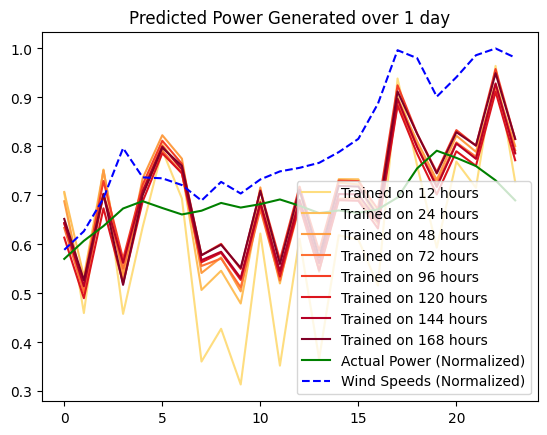

Time steps to predict: 48
[0.22823533 0.5679827  0.73645866 0.5483879  0.7466419  0.7370204
 0.7679328  0.3432875  0.659495   0.73255134 0.4293672  0.6995425
 0.77606654 0.7829052  0.758857   0.6999167  0.5443764  0.93190694
 0.9318867  0.9328613  0.9432168  0.753482   0.54297006 0.9123535
 0.5654247  0.64475405 0.8644711  0.589452   0.43922755 0.5412966
 0.82736206 0.4882714  0.6281022  0.6395658  0.6626955  0.68364894
 0.52889216 0.5703981  0.35854957 0.06407243 0.43261817 0.5759007
 0.570722   0.5988964  0.45934692 0.18625599 0.3384997  0.5248215 ]
[0.36703354 0.61381274 0.73993444 0.5977326  0.7884401  0.76897305
 0.7970683  0.4947347  0.71014035 0.76840556 0.55520356 0.75619376
 0.8131039  0.8257904  0.81719184 0.7870369  0.6779687  0.89778405
 0.90537494 0.9182048  0.9127461  0.7983373  0.66289264 0.8977955
 0.69255555 0.7535671  0.8803991  0.7393227  0.66410327 0.72429955
 0.86651874 0.6472434  0.72261506 0.7131865  0.68479574 0.67660683
 0.5270497  0.52912164 0.34714723 0.17373

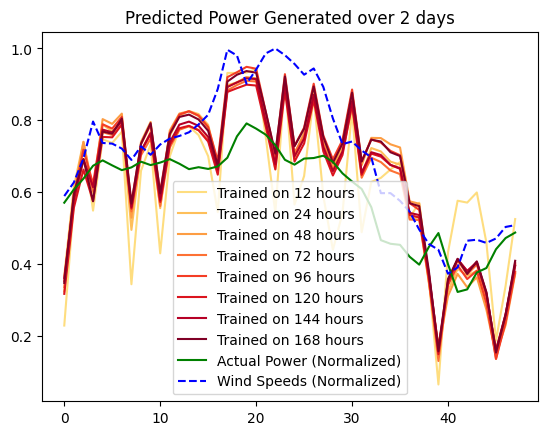

Time steps to predict: 168
[ 0.34952936  0.22645506  0.7099469   0.48903254  0.4654899   0.79058325
  0.6610503   0.23547807  0.26919004  0.30510497  0.3755125   0.6303433
  0.44232944  0.7363949   0.7880477   0.4849228   0.658919    0.88165164
  0.69516957  0.9000249   0.9636607   0.5715498   0.56865895  0.90432763
  0.9527056   0.68618     0.7789104   0.4299294   0.3430387   0.30781743
  0.81926835  0.43270686  0.4604567   0.580268    0.3493726   0.47250763
  0.2653741   0.4645008   0.26352885  0.52717006  0.56177163  0.2017543
  0.3119518   0.05522697  0.61620724  0.21157798  0.6326525   0.42971995
  0.21880984  0.60259855  0.73249865  0.724352    0.7954575   0.20075732
  0.75735235  0.5098516   0.5533663   0.43606505  0.53666127  0.4586865
  0.70922065  0.52201116  0.36313987  0.35127363  0.44909254  0.53273106
  0.30998248  0.55492914  0.5958675   0.09482676  0.38432452  0.537845
  0.43090412  0.81248605  0.7665819   0.26048705  0.46730068  0.6058003
  0.2073867   0.70119894  0.17

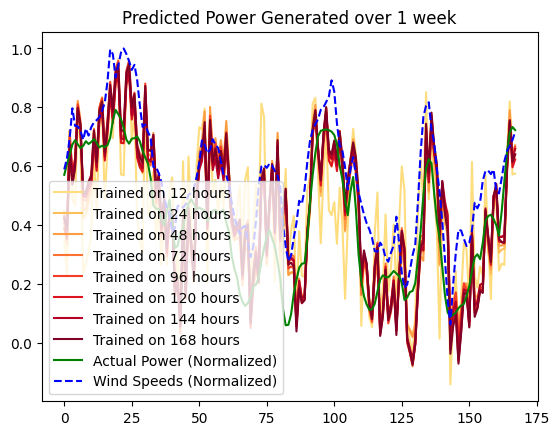

Time steps to predict: 720
[ 0.6736698   0.7054038   0.83186066  0.8462883   0.73892105  0.7217239
  0.45365325  0.62762773  0.45211712  0.7772038   0.4944519   0.8557563
  0.50428927  0.58929884  0.65331924  0.41909733  0.84253705  0.7839365
  0.8144164   0.86753607  0.95680714  0.9411651   0.6687702   0.6567279
  0.6277231   0.91286576  0.54361427  0.39950994  0.7498224   0.30195138
  0.49055532  0.19703063  0.65044904  0.34670845  0.70462155  0.17305776
  0.439243    0.10808371  0.47416273  0.2031857   0.14198396  0.36930278
  0.5216681   0.4612426   0.56979454  0.16022697  0.46273842  0.7083912
  0.5396433   0.77186227  0.6967194   0.4299852   0.45072684  0.33505723
  0.74771166  0.6246234   0.37607166  0.3191612   0.43233404  0.5849323
  0.7353301   0.48125544  0.29058948  0.00874884  0.5525185   0.14250168
  0.57870793  0.32403135  0.2812078   0.09610015  0.36626837  0.31238797
  0.58939016  0.24370745  0.3657986   0.3997986   0.19760334  0.54700494
  0.5613866   0.6886878   0.04

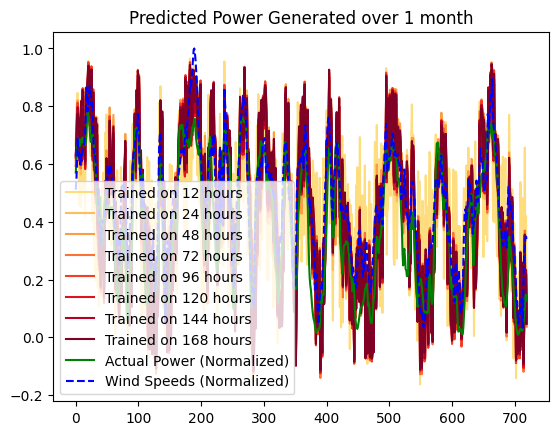

In [4]:
(speed, power) = dataset

models = [model_12hr, 
          model_24hr, 
          model_48hr, 
          model_72hr, 
          model_96hr, 
          model_120hr, 
          model_144hr,
          model_168hr]
model_labels = [12, 24, 48, 72, 96, 120, 144, 168]

scales = ['1 day', '2 days', '1 week', '1 month']
upper_bounds = [24, 24 * 2, 24 * 7, 24 * 30]

M = len(models)

for i in range(len(scales)):
    scale = scales[i]
    T = upper_bounds[i]
    x = np.arange(0, T)

    input = speed[:T].unsqueeze(0)
    target = power[:T]

    norm_speed = input.squeeze() / torch.max(input)
    cmap = plt.get_cmap('YlOrRd', M + 2)
    print(f'Time steps to predict: {T}')
    # Use same quantiles for all models to ensure "fairness" in visualizing predictions
    quantiles = random_quantiles(size=(T), low=0.01, high=0.99)
    for j in range(M):
        model = models[j]
        label = model_labels[j]
        predicted_power = model(input, quantiles).detach().cpu().numpy().squeeze()
        print(predicted_power)
        plt.plot(x, predicted_power, color=cmap(j+2), label=f'Trained on {label} hours')
    plt.plot(x, target, 'g', label='Actual Power (Normalized)')
    plt.plot(x, norm_speed, '--b', label='Wind Speeds (Normalized)')
    plt.title(f'Predicted Power Generated over {scale}')
    plt.legend()
    plt.show()

[]

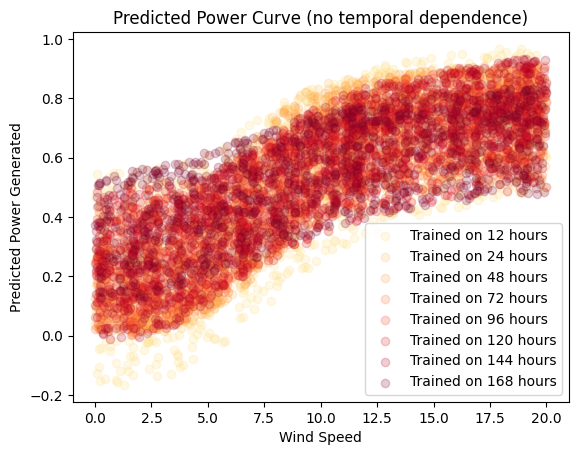

In [16]:
N = 1000
random_wind_speeds = np.random.uniform(0, 20, N)

for i in range(M):
    model = models[i]
    label = model_labels[i]
    preds = []
    cmap = plt.get_cmap('YlOrRd', M + 2)

    for speed in random_wind_speeds:
        input = torch.tensor([speed], dtype=torch.float).unsqueeze(0)
        alpha = random_quantiles(1, 0.01, 0.99)
        pred = model(input, alpha).detach().cpu().numpy().squeeze()
        preds.append(pred)
    plt.scatter(random_wind_speeds, preds, alpha=0.2, color=cmap(i+2), label=f'Trained on {label} hours')
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (no temporal dependence)')
plt.legend()
plt.plot()

[]

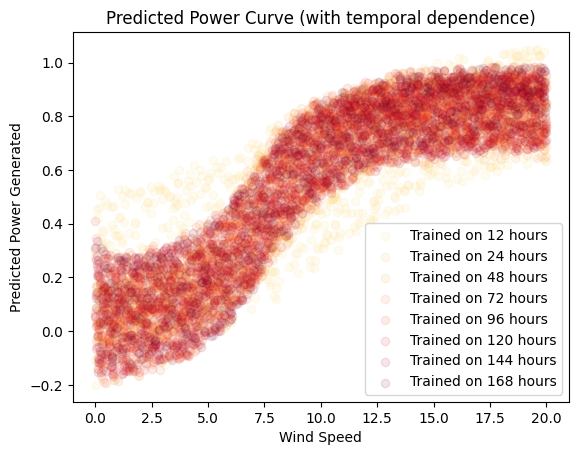

In [19]:
N = 1000
random_wind_speeds = np.linspace(0, 20, N)
cmap = plt.get_cmap('YlOrRd', M + 2)

for i in range(M):
    model = models[i]
    label = model_labels[i]
    input = torch.tensor(random_wind_speeds, dtype=torch.float).unsqueeze(0)
    alpha = random_quantiles(N, 0.01, 0.99)
    preds = model(input, alpha).detach().cpu().numpy().squeeze()
    plt.scatter(random_wind_speeds, preds, alpha=0.1, color=cmap(i+2), label=f"Trained on {label} hours")
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (with temporal dependence)')
plt.legend()
plt.plot()

/var/folders/rj/tjcj95tx32q97ft46gzv_wym0000gn/T/ipykernel_9565/3885840982.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)


[]

/Users/zachl/Desktop/WindEnergyForecasting/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


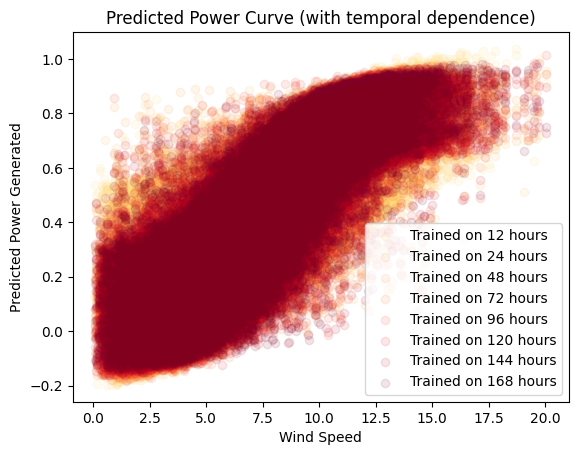

In [6]:
cmap = plt.get_cmap('YlOrRd', M + 2)

for i in range(M):
    model = models[i]
    label = model_labels[i]
    input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)
    alpha = random_quantiles(len(speed), 0.01, 0.99)
    preds = model(input, alpha).detach().cpu().numpy().squeeze()
    plt.scatter(speed, preds, alpha=0.1, color=cmap(i+2), label=f"Trained on {label} hours")
plt.ylabel('Predicted Power Generated')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (on historical data)')
plt.legend()
plt.plot()

/var/folders/rj/tjcj95tx32q97ft46gzv_wym0000gn/T/ipykernel_9565/3380421353.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)


[]

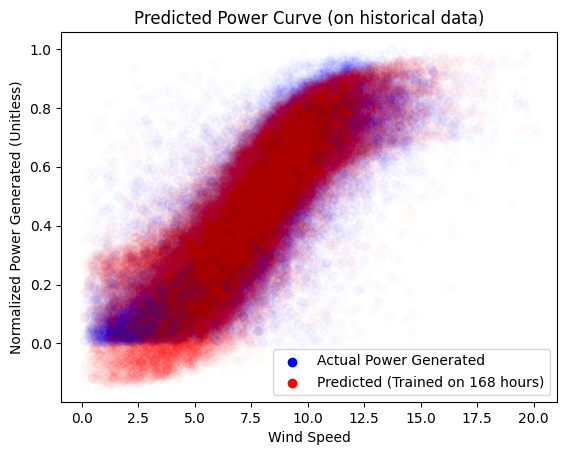

In [10]:
from matplotlib.collections import PathCollection
from matplotlib.legend_handler import HandlerPathCollection, HandlerLine2D

cmap = plt.get_cmap('YlOrRd', M + 2)

model = model_168hr
input = torch.tensor(speed, dtype=torch.float).unsqueeze(0)
alpha = random_quantiles(len(speed), 0.01, 0.99)
preds = model(input, alpha).detach().cpu().numpy().squeeze()

plt.scatter(speed, power, alpha=0.01, color='b', label=f"Actual Power Generated")
plt.scatter(speed, preds, alpha=0.01, color='r', label=f"Predicted (Trained on 168 hours)")
plt.ylabel('Normalized Power Generated (Unitless)')
plt.xlabel('Wind Speed')
plt.title('Predicted Power Curve (on historical data)')

def update(handle, orig):
    handle.update_from(orig)
    handle.set_alpha(1)

plt.legend(handler_map={PathCollection : HandlerPathCollection(update_func= update),
                        plt.Line2D : HandlerLine2D(update_func = update)})
plt.plot()